<a href="https://colab.research.google.com/github/Ebratul/BRICK_BREAKER_Game/blob/main/DL/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
img = image.load_img('/content/cat.jpg', target_size = (200, 200))

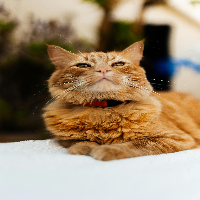

In [ ]:
img

In [ ]:
type(img) #python image library

PIL.Image.Image

In [ ]:
datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    # fill_mode = 'nearest'
    fill_mode = 'constant'
)

In [ ]:
img = image.img_to_array(img)

In [ ]:
img.shape

(200, 200, 3)

In [ ]:
input_batch = img.reshape(1, 200, 200, 3)

In [ ]:
i = 0
for output  in datagen.flow(input_batch, batch_size=1, save_to_dir = '/content/aug'):
  i = i+1
  if i == 10:
    break

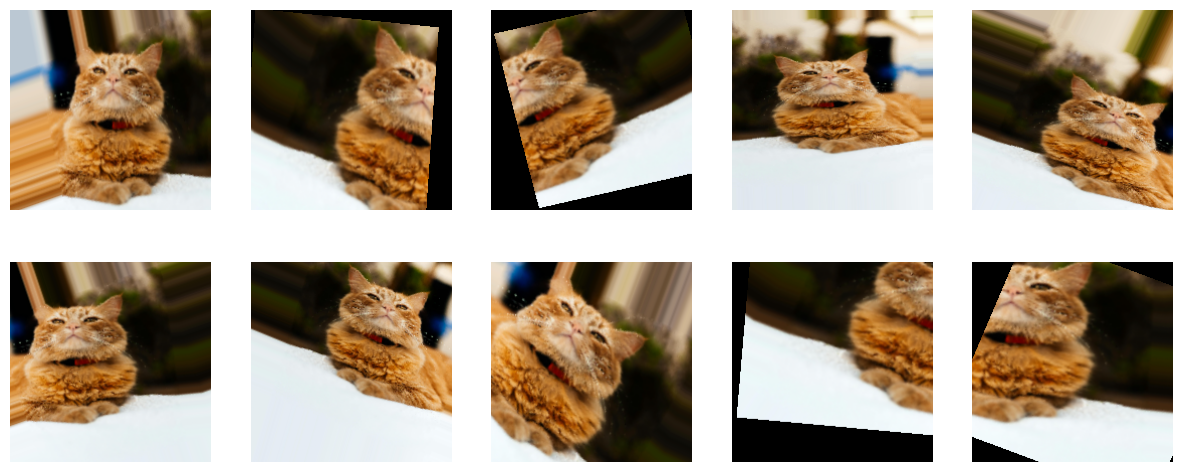

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

folder = '/content/aug'
files = os.listdir(folder)

plt.figure(figsize=(15, 6))
for i, file in enumerate(files[:10]):  # show all 10 images
    img_path = os.path.join(folder, file)
    img = mpimg.imread(img_path)
    plt.subplot(2, 5, i+1)  # 2 rows, 5 columns
    plt.imshow(img)
    plt.axis('off')
plt.show()


In [ ]:
input_batch.shape

(1, 200, 200, 3)

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [7]:
!kaggle competitions download -c dogs-vs-cats

 98% 794M/812M [00:07<00:00, 292MB/s]
100% 812M/812M [00:07<00:00, 111MB/s]


In [1]:
!nvidia-smi

Tue Feb 17 02:28:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
torch.cuda.is_available()

True

In [3]:
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [8]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()


In [9]:
zip_ref = zipfile.ZipFile('/content/train.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [10]:
zip_ref = zipfile.ZipFile('/content/test1.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [11]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [12]:
import os
import shutil

# Train ফোল্ডারে cats এবং dogs সাব-ফোল্ডার তৈরি
os.makedirs("/content/train/cats", exist_ok=True)
os.makedirs("/content/train/dogs", exist_ok=True)

# Test ফোল্ডারে cats এবং dogs সাব-ফোল্ডার তৈরি
os.makedirs("/content/test1/cats", exist_ok=True)
os.makedirs("/content/test1/dogs", exist_ok=True)

# Train ফোল্ডারের ইমেজগুলো ভাগ করা (prefix দিয়ে)
for file in os.listdir("/content/train"):
    if file.startswith("cat"):
        shutil.move(f"/content/train/{file}", "/content/train/cats/")
    elif file.startswith("dog"):
        shutil.move(f"/content/train/{file}", "/content/train/dogs/")

# Test ফোল্ডারের ইমেজগুলো ভাগ করা (number দিয়ে split)
for file in os.listdir("/content/test1"):
    if file.endswith(".jpg"):
        file_id = int(file.split(".")[0])  # নাম থেকে সংখ্যা বের করা
        if file_id < 12500:
            shutil.move(f"/content/test1/{file}", "/content/test1/cats/")
        else:
            shutil.move(f"/content/test1/{file}", "/content/test1/dogs/")

# চেক করা কতগুলো ইমেজ আছে
print("Train Cats:", len(os.listdir("/content/train/cats")))
print("Train Dogs:", len(os.listdir("/content/train/dogs")))
print("Test Cats:", len(os.listdir("/content/test1/cats")))
print("Test Dogs:", len(os.listdir("/content/test1/dogs")))

Train Cats: 12500
Train Dogs: 12500
Test Cats: 12499
Test Dogs: 1


In [14]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,   # correct spelling
    zoom_range = 0.2,
    horizontal_flip = True
)

# this is the augmentation configuration we will use for testing:
test_datagen = ImageDataGenerator(
    rescale = 1./255
)

In [19]:
batch_size = 32

#this is a generator that will read picture found in
train_generator = train_datagen.flow_from_directory(
    '/content/train',
    target_size = (150, 150),
    batch_size = batch_size,
    class_mode = 'binary'
)

#this is a generator that will read picture found in
validation_generator = train_datagen.flow_from_directory(
    '/content/test1',
    target_size = (150, 150),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 25000 images belonging to 2 classes.
Found 12500 images belonging to 2 classes.


In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
from tensorflow.keras.optimizers import Adam

In [34]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

# Build CNN
model = Sequential()

# Block 1
model.add(Conv2D(32, kernel_size=(3,3), padding='same', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Dropout(0.4))   # not needed this early

# Block 2
model.add(Conv2D(64, kernel_size=(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Dropout(0.4))   # optional

# Block 3
model.add(Conv2D(128, kernel_size=(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
# model.add(Dropout(0.4))   # optional

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(128))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))   # keep dropout here

model.add(Dense(64))
model.add(BatchNormalization())
model.add(Activation('relu'))
# model.add(Dropout(0.4))   # optional

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),   # tuned learning rate
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,411,777 (20.64 MB)

 Trainable params: 5,410,945 (20.64 MB)

 Non-trainable params: 832 (3.25 KB)

In [35]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 150, 150, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,411,777 (20.64 MB)

 Trainable params: 5,410,945 (20.64 MB)

 Non-trainable params: 832 (3.25 KB)

In [37]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    steps_per_epoch = 2000 // batch_size,   # spelling fixed
    epochs = 200,
    validation_data = validation_generator,
    validation_steps = 800 // batch_size,
    callbacks = [early_stop]                # comma added
)


Epoch 1/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 310ms/step - accuracy: 0.6457 - loss: 0.6291 - val_accuracy: 1.0000 - val_loss: 0.2757
Epoch 2/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 318ms/step - accuracy: 0.6949 - loss: 0.5729 - val_accuracy: 1.0000 - val_loss: 0.1498
Epoch 3/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 303ms/step - accuracy: 0.6987 - loss: 0.6104 - val_accuracy: 0.9912 - val_loss: 0.3029
Epoch 4/200
62/62 ━━━━━━━━━━━━━━━━━━━━ 19s 309ms/step - accuracy: 0.7296 - loss: 0.5449 - val_accuracy: 0.7200 - val_loss: 0.6014


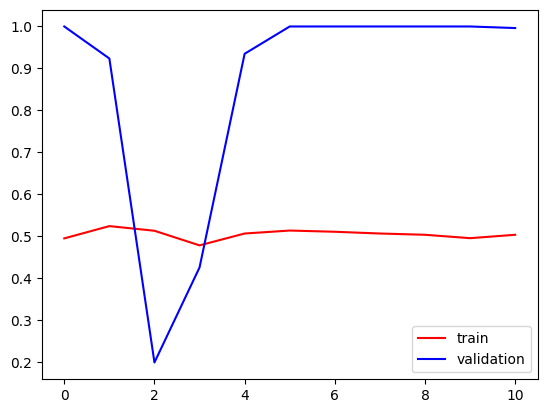

In [32]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

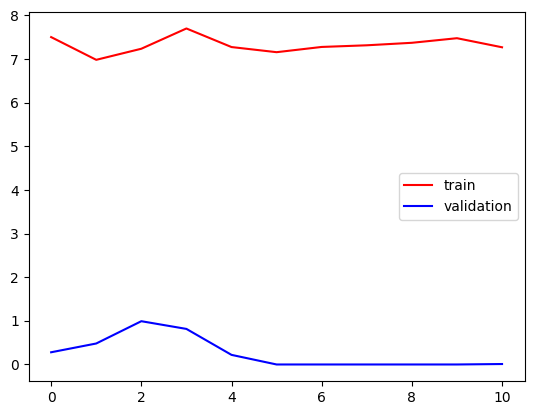

In [33]:
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

In [38]:
import tensorflow as tf
import numpy as np
import cv2

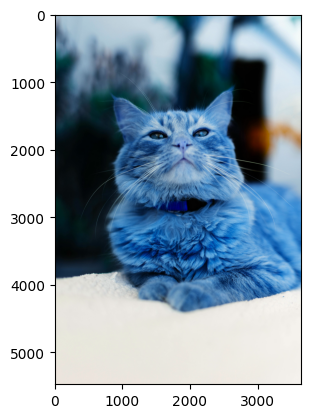

In [39]:
# ইমেজ লোড করা
test_path = "/content/cat.jpg"
test_img = cv2.imread(test_path)
plt.imshow(test_img)

In [40]:
test_img.shape

(5472, 3648, 3)

In [50]:

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Path to your test image
test_path = "/content/image.jpeg"   # change to your image path

# ✅ Load image using Keras utilities
img = tf.keras.utils.load_img(test_path, target_size=(150, 150))   # resize
img_array = tf.keras.utils.img_to_array(img)                       # convert to array
img_array = np.expand_dims(img_array, axis=0)                      # add batch dimension
img_array = img_array / 255.0

In [51]:
# ✅ Prediction
prediction = model.predict(img_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


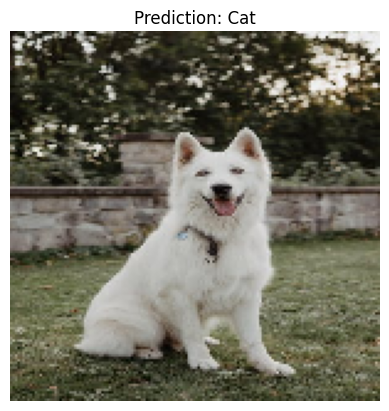

Raw prediction value: 0.21694341


In [52]:
# ✅ Show image with prediction result
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {'Dog' if prediction[0][0] > 0.5 else 'Cat'}")
plt.show()

print("Raw prediction value:", prediction[0][0])


In [65]:
import os
import numpy as np
import tensorflow as tf
import pandas as pd

# ✅ Path to test images folder (your dataset)
test_dir = "/content/test1"   # updated path

# Collect all file names
test_files = [f for f in os.listdir(test_dir) if f.endswith(".jpg")]
test_files.sort()  # keep consistent order

# ✅ Predictions list
predictions = []

for fname in test_files:
    img_path = os.path.join(test_dir, fname)
    img = tf.keras.utils.load_img(img_path, target_size=(256, 256))
    img_array = tf.keras.utils.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    pred = model.predict(img_array)[0][0]
    predictions.append(pred)

# Convert predictions to binary labels (Dog=1, Cat=0)
labels = [1 if p > 0.5 else 0 for p in predictions]

# Build submission DataFrame
submission = pd.DataFrame({
    "id": test_files,
    "label": labels
})

# Save CSV
submission.to_csv("submission.csv", index=False)
print("Submission file saved as submission.csv")


Submission file saved as submission.csv
